In [1]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
plt.rcParams.update({
    'figure.figsize': (3.6, 2.7), 'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 'small', 'ytick.labelsize': 'small',
    'legend.fontsize': 'small', 'axes.titlesize': 'medium',
    'axes.spines.top': False, 'axes.spines.right': False,
    'image.interpolation': 'nearest', 'savefig.dpi': 100,
})

import os
import pickle
from pathlib import Path
import networkx as nx
import numpy as np
from jarvis.utils import tqdm

from hexarena import STORE_DIR
FIG_DIR = Path('figures')
os.makedirs(FIG_DIR, exist_ok=True)
rng = np.random.default_rng()

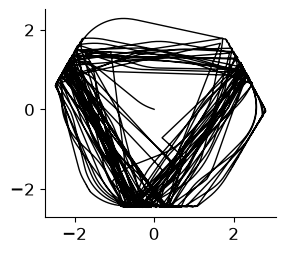

In [14]:
from hexarena.utils import load_monkey_data, align_monkey_data, get_valid_blocks

subject = 'humans'
block_data = load_monkey_data(subject, '1', 0)
align_monkey_data(block_data)
xyz = block_data['pos_xyz']

_, ax = plt.subplots()
ax.plot(xyz[:, 0], xyz[:, 1], linewidth=1, color='black')
ax.set_aspect('equal')
plt.show()

In [17]:
block_infos = get_valid_blocks(subject)

In [27]:
from hexarena.scripts.common import create_env

resol = 4
env = create_env(env_kw={'arena': {'resol': resol}})
n_tiles = env.arena.n_tiles
edges = np.arange(n_tiles+1)-0.5

n_subjects = 5
for subject_idx in range(n_subjects):
    save_pth = STORE_DIR/f'occupancy_human{subject_idx}.pkl'
    if save_pth.exists():
        continue
    block_ids = [block_id for block_id in block_infos if block_id[0]==str(subject_idx+1)]
    
    pos_counts = np.zeros((2, n_tiles), dtype=int)
    gaze_counts = np.zeros((2, n_tiles), dtype=int)
    for session_id, block_idx in block_ids:
        block_data = load_monkey_data(subject, session_id, block_idx)
        for i in range(2):
            if i==1:
                align_monkey_data(block_data)
            env_data = env.convert_experiment_data(block_data, arena_radius=2.85)
            pos_counts[i] += np.histogram(env_data['pos'][mask], edges)[0]
            gaze_counts[i] += np.histogram(env_data['gaze'][mask], edges)[0]
    with open(save_pth, 'wb') as f:
        pickle.dump({
            'resol': resol, 'num_tiles': n_tiles, 'pos_counts': pos_counts, 'gaze_counts': gaze_counts,
        }, f)

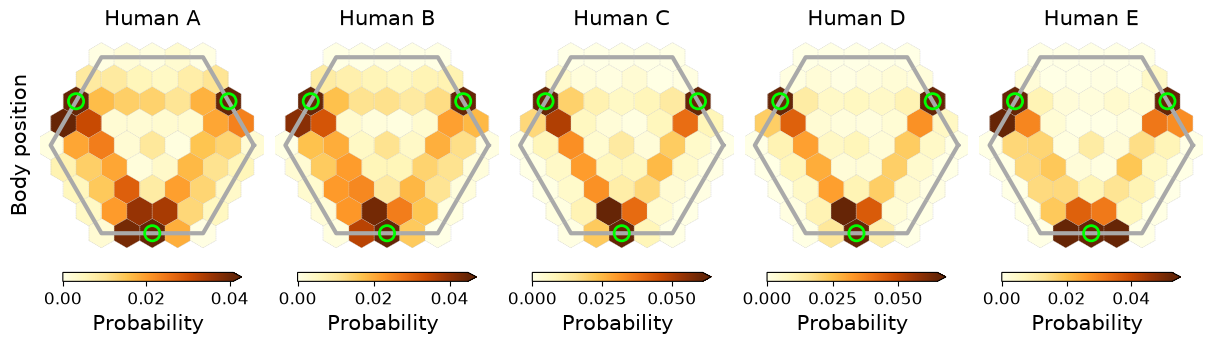

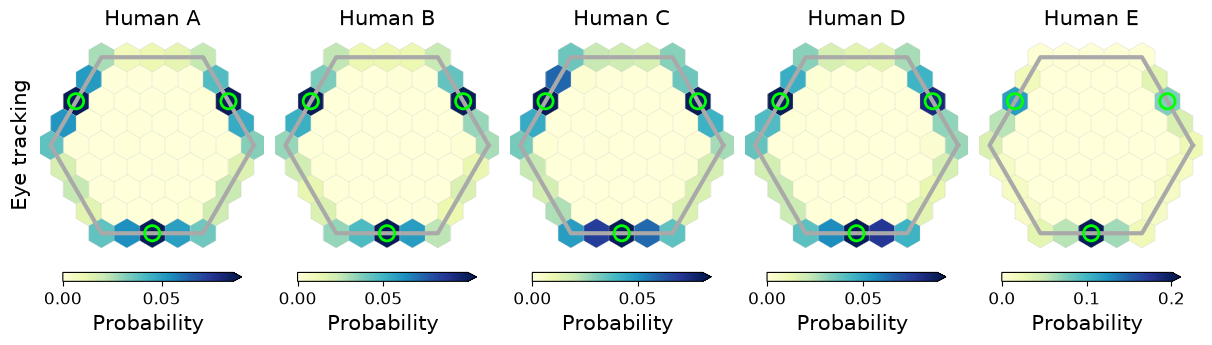

In [40]:
for k in range(2):
    if k==0:
        key = 'pos_counts'
        cmap = 'YlOrBr'
        label = 'Body position'
    if k==1:
        key = 'gaze_counts'
        cmap = 'YlGnBu'
        label = 'Eye tracking'
    fig, axes = plt.subplots(1, n_subjects, figsize=(3*n_subjects, 4), gridspec_kw={'hspace': 0.05, 'wspace': 0.05})
    for j in range(n_subjects):
        save_pth = STORE_DIR/f'occupancy_human{j}.pkl'
        with open(save_pth, 'rb') as f:
            saved = pickle.load(f)
        counts = saved[key][1]
        probs = counts/counts.sum(axis=-1, keepdims=True)
        vmax = probs.max()
        ax = axes[j]
        env.arena.plot_map(
            ax, probs, vmax=vmax*0.3 if k==0 else vmax*0.6, door=i==0, cmap=cmap,
            cbar_kw={'label': 'Probability', 'disable': i==0, 'extend': 'max'},
        )
        axes[j].set_title('Human '+chr(ord('A')+j))
    axes[0].text(-1.4, 0, label, rotation='vertical', va='center')
    fig.savefig(FIG_DIR/'occupancy_human_{}.svg'.format(key.split('_')[0]))